# Noise Sensitivity Sweep: Burgers Equation

- PDE: $\partial_t u + u \partial_x u = \frac{0.1}{\pi} \partial_{xx} u$
- Unknown: initial condition $a(x) = u(x, t=0)$
- Latent dimension: $d = 16$
- Sweep: SNR $\in \{50, 35, 25, 15\}$ dB and clean baseline

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "snr": n}
    for s, n in itertools.product([42, 123, 7], [None, 50, 35, 25, 15])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from pathlib import Path

import numpyro

from src.problems.burgers import Burgers, mollifier_burgers
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    plot_calibration_overlay, plot_noise_sweep, plot_sweep_summary_table,
    plot_trace, bootstrap_metric_ci,
    plot_burgers_field_comparison, plot_burgers_std_multi_panel,
    compute_prior_predictive, build_prior_result,
    compute_sigma_from_map, recommended_nuts_config, mcmc_reliability_flag,
    compute_error_std_correlation,
    chi2_ppc,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood, make_numpyro_model,
    run_map_estimation, tune_sigma, decode_initial_condition_burgers,
    add_noise_snr_with_sigma,
    sample_unconditional_prior, decode_posterior_batched,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics,
    build_mcmc_result, save_experiment_result,
    load_cross_seed_results, cross_seed_metric_summary,
)

CHECKPOINT_PATH = Path('../runs/final_burgers/weights/best.pt')
TEST_DATA_PATH = '../data/burgers/viscid_test_in.mat'
TEST_IDX = 0
N_OBS = 100
SNR_LEVELS = [50, 35, 25, 15]
NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
problem = Burgers(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

n_points = problem.get_n_points()

print(f"Latent dim: {d}")
print(f"n_mesh: {problem.n_mesh}, n_time: {problem.n_time}")

Loading data...
  Test: a=(200, 128, 1), u=(200, 12928, 1)
Setting up grids and test functions...


  int_grid: (10, 1), v: (10, 1)
Building models...


  Initialized enc: 25,808 params


  Initialized u: 103,006 params


  Initialized nf: 60,480 params
Loading checkpoint: ../runs/final_burgers/weights/best.pt
  Loaded enc
  Loaded u
  Loaded nf


Latent dim: 16
n_mesh: 128, n_time: 101


## 2. Inversion Config

In [4]:
inv_config = InversionConfig(
    epochs=500,
    loss_weights=LossWeights(pde=1.0, data=50.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=100, gamma=0.8),
)

## 3. Per-Seed Loop


######################################################################
# SEED = 123
######################################################################


x_obs: (1, 100, 2), u_obs_clean: (1, 100, 1)
a_true range: [-0.253, 0.253]


Prior predictive: a_err=0.9602, CRPS=0.0639, cov95=0.9922


  Inversion grid: n_mesh_or_grid=7, n_grid=7


Loss weights: pde=1.0, data=50.0, target=u


...

sample: 100%|██████████| 2000/2000 [03:19<00:00, 10.22it/s]

sample: 100%|██████████| 2000/2000 [03:19<00:00, 10.04it/s]

MCMC warmup: 518.8s, sampling: 199.1s

                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.05      0.01      0.05      0.04      0.06   4936.96      1.00
   beta[1]      0.03      0.02      0.04      0.00      0.07   6382.17      1.00
   beta[2]      0.03      0.01      0.03      0.01      0.05   5522.47      1.00
   beta[3]      0.12      0.01      0.12      0.10      0.14   4941.06      1.00
   beta[4]      0.02      0.01      0.02     -0.01      0.04   4709.26      1.00
   beta[5]      0.06      0.01      0.06      0.05      0.08   4345.66      1.00
   beta[6]      0.05      0.02      0.05      0.02      0.08   7144.93      1.00
   beta[7]     -0.07      0.01     -0.07     -0.09     -0.06   4642.88      1.00
   beta[8]      0.06      0.02      0.06      0.04      0.09   5233.87      1.00
   beta[9]      0.09      0.01      0.09      0.08      0.11   5868.35      1.00
  beta[10]      0.09      0.01      0.09      0.07      0.10   6284.44

  Chi2 PPC: chi2=0.40, p=1.0000 (df=100)


Saved structured result to: /workspace/experiments/results/structured/noise_sweep/burgers_2026-06-14T12-22-41_seed123.json

  Burgers — Noise Sensitivity
  Condition                  CRPS(a)    Coverage    CI Width   Sharpness   Rel.L2(a)     Diverg.     ESS min       R-hat    Flag
  ------------------------------------------------------------------------------------------------------------------------------
  Clean                     0.006730     95.31%     0.062644    0.016028    0.102259           0      4067.3      1.0014    PASS



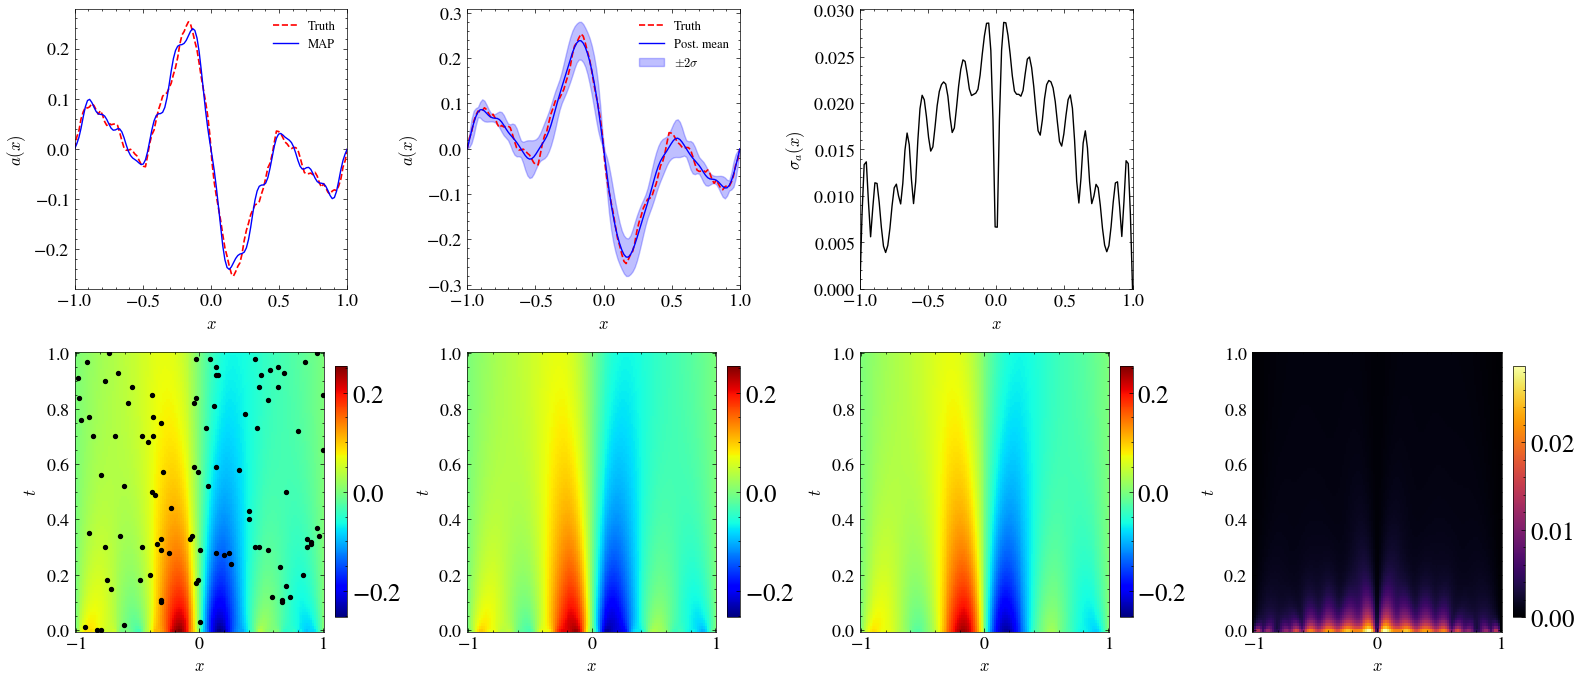

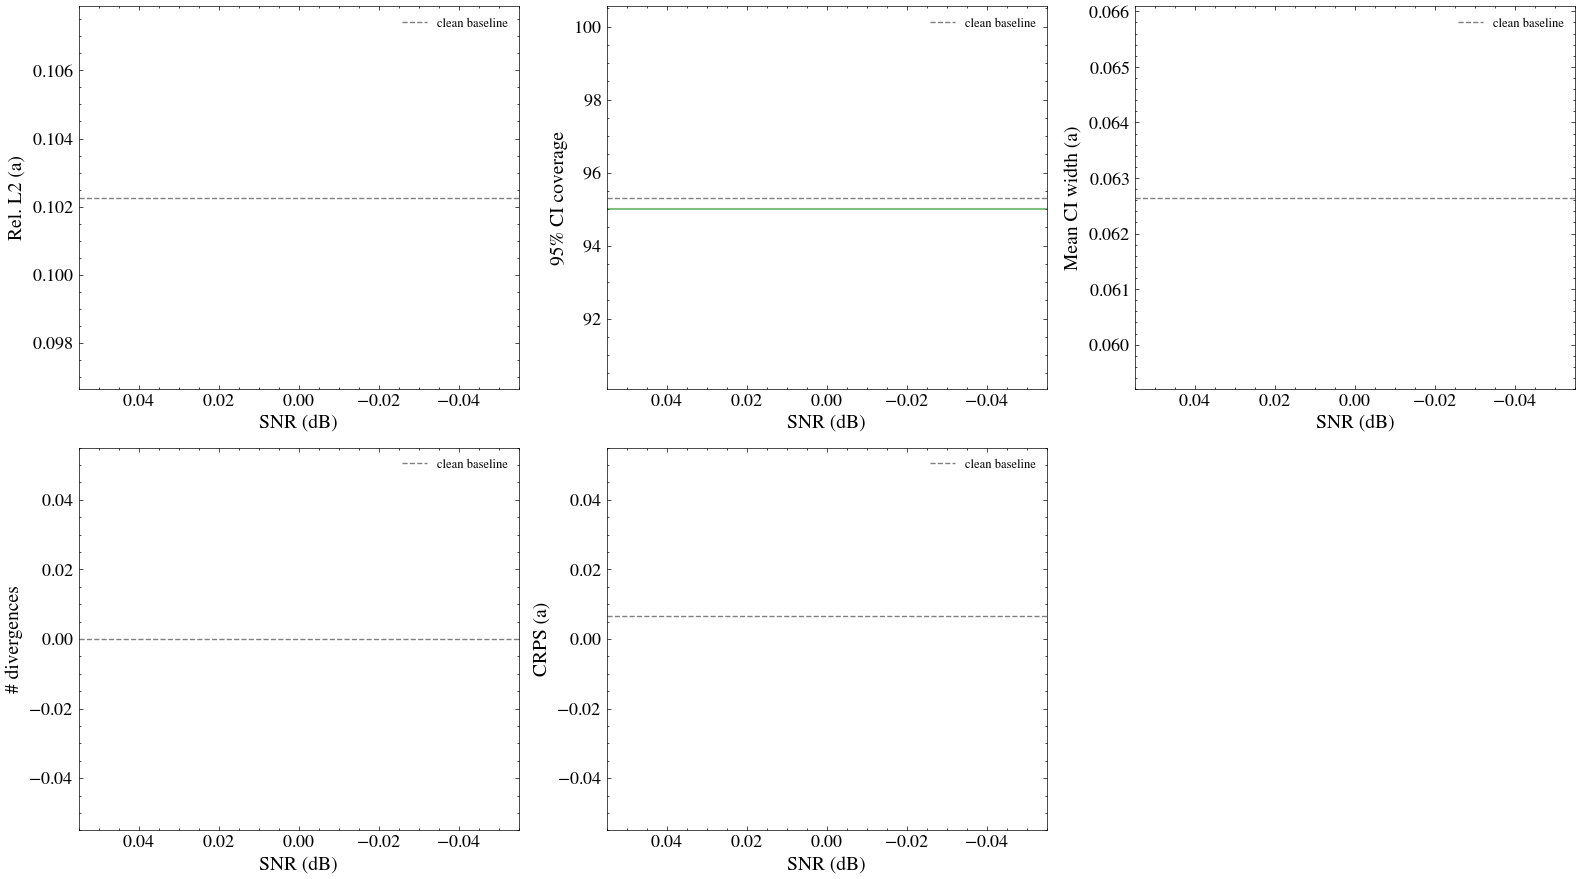

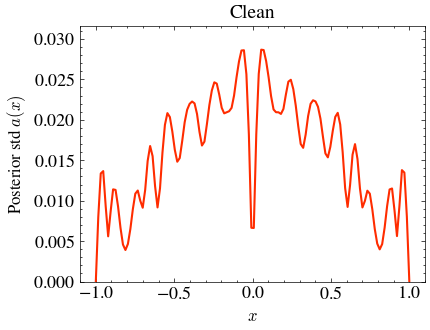

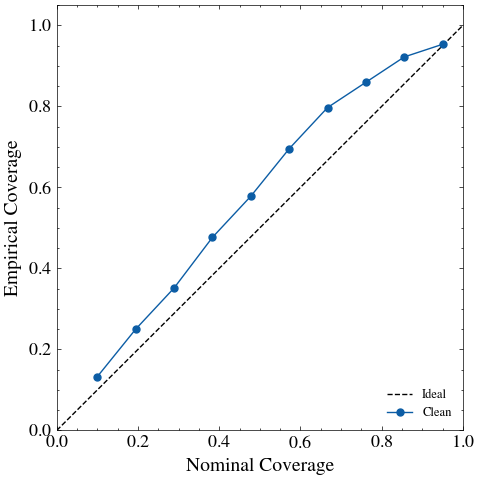

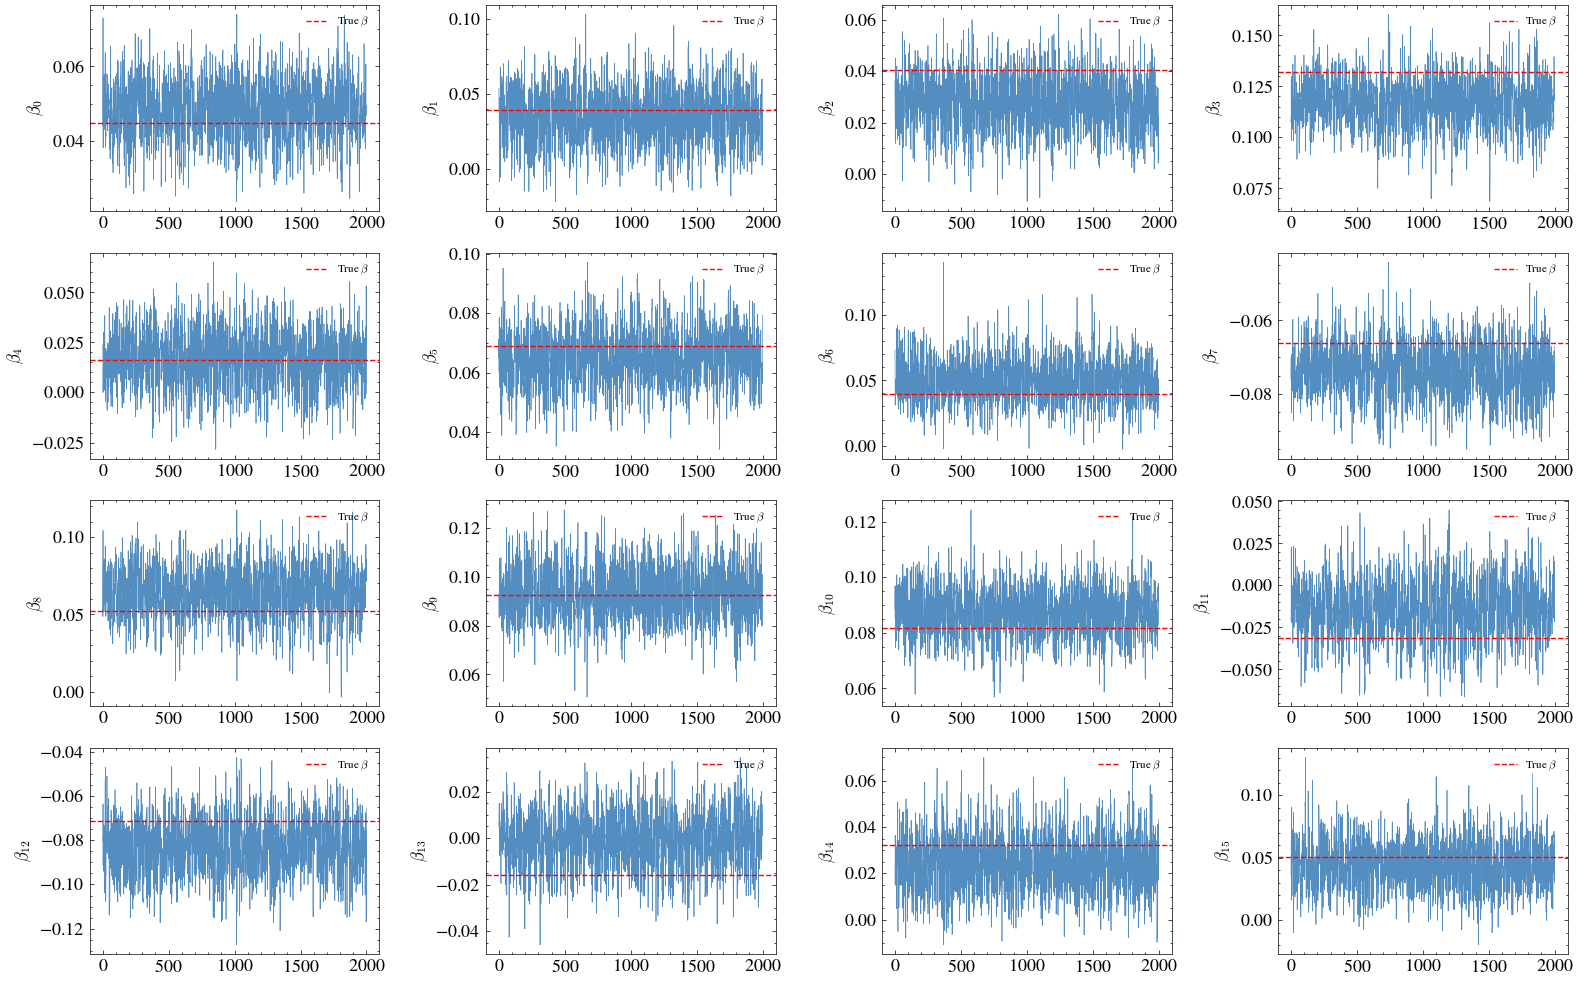

In [5]:
from results_schema import ExperimentResult
from datetime import datetime

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'#'*70}\n# SEED = {SEED}\n{'#'*70}")

    FIGURE_DIR = Path(f'figures/noise_sweep_burgers/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)
    obs_data = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices)

    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs_clean = obs_data['u_obs']
    a_true = obs_data['a_true']
    u_true = obs_data['u_true']

    print(f"x_obs: {x_obs.shape}, u_obs_clean: {u_obs_clean.shape}")
    print(f"a_true range: [{float(a_true.min()):.3f}, {float(a_true.max()):.3f}]")

    # ### Prior Predictive Baseline
    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    # ### MAP Baseline
    map_result = run_map_estimation(problem, params, x_obs, u_obs_clean, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = float(jnp.linalg.norm(a_map[:, 0] - a_true[0, :, 0]) / jnp.linalg.norm(a_true[0, :, 0]))
    print(f"MAP Rel. L2 (a): {rmse_map_a:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (×{inv_config.loss_weights.pde})', f'Data (×{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### Sigma Tuning via Pilot MCMC (clean observations)
    log_lik_fn_clean = make_gaussian_log_likelihood(problem, params, mollifier_burgers, x_obs, u_obs_clean)
    numpyro_model_clean = make_numpyro_model(d, log_prior_fn, log_lik_fn_clean)

    SIGMA_CANDIDATES = [0.001, 0.002, 0.003, 0.005, 0.007, 0.01]

    def _model_factory(sigma):
        return lambda: numpyro_model_clean(sigma=sigma)

    def _decode_fn(beta_samples):
        return decode_initial_condition_burgers(problem, params, mollifier_burgers, beta_samples)

    _nuts_cfg_tune = recommended_nuts_config(d, sigma=0.005)
    rng, tune_key = jax.random.split(rng)
    tuned_sigma, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_mode,
        sigma_candidates=SIGMA_CANDIDATES,
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=np.array(a_true[0, :, 0]),
        target_accept_prob=_nuts_cfg_tune['target_accept_prob'],
    )
    print(f"sigma (tuned): {tuned_sigma:.6f}")

    # ### Run conditions
    def run_condition(snr_db, rng_key):
        rng_key, noise_key, mcmc_key = random.split(rng_key, 3)

        if snr_db is not None:
            u_obs_noisy, noise_sigma = add_noise_snr_with_sigma(u_obs_clean, snr_db, noise_key)
            label = f"SNR={snr_db}dB"
            print(f"\n{'='*60}\n  {label} (noise_sigma={noise_sigma:.6f})\n{'='*60}")
        else:
            u_obs_noisy = u_obs_clean
            noise_sigma = None
            label = "Clean"
            print(f"\n{'='*60}\n  {label}\n{'='*60}")

        sigma = max(noise_sigma if noise_sigma is not None else 0.0, tuned_sigma)

        log_lik_fn = make_gaussian_log_likelihood(problem, params, mollifier_burgers, x_obs, u_obs_noisy)
        numpyro_model = make_numpyro_model(d, log_prior_fn, log_lik_fn)

        nuts_cfg = recommended_nuts_config(d, sigma)
        print(f"  sigma={sigma} | target_accept_prob={nuts_cfg['target_accept_prob']}, "
              f"max_tree_depth={nuts_cfg['max_tree_depth']}")

        mcmc, timing = run_mcmc(
            numpyro_model, {"beta": beta_mode}, {"sigma": sigma}, mcmc_key,
            NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
        )
        mcmc.print_summary(exclude_deterministic=True)

        diag = extract_mcmc_diagnostics(mcmc, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)
        beta_samples = diag['samples']

        a_pred_all, u_pred_all = decode_posterior_batched(problem, params, beta_samples, x_full)

        metrics = compute_standard_metrics(a_pred_all, a_true_np)

        spearman_rho, spearman_p = compute_error_std_correlation(
            a_true_np, np.mean(a_pred_all, axis=0), np.std(a_pred_all, axis=0),
        )

        u_pred_at_obs = u_pred_all[:, np.array(obs_indices)]
        u_obs_np = np.array(u_obs_noisy[0, :, 0])
        chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, sigma)
        print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={u_obs_np.shape[0]})")

        return {
            'label': label, 'snr_db': snr_db,
            'noise_sigma': noise_sigma, 'sigma': sigma,
            'beta_samples': np.array(beta_samples),
            'beta_by_chain': diag['by_chain'],
            'beta_for_trace': diag['by_chain'][0],
            'a_pred_all': a_pred_all, 'u_pred_all': u_pred_all,
            'a_mean': np.mean(a_pred_all, axis=0),
            'a_std': np.std(a_pred_all, axis=0),
            'u_mean': np.mean(u_pred_all, axis=0),
            'u_std': np.std(u_pred_all, axis=0),
            'ess_min': diag['ess_min'],
            'rhat_max': diag['rhat_max'],
            'rhat_mean': diag['rhat_mean'],
            'n_div': diag['n_div'],
            'reliability_flag': diag['flag'],
            'chi2_ppc': chi2_stat,
            'chi2_ppc_pvalue': chi2_pval,
            'spearman_rho_error_std': spearman_rho,
            'spearman_pvalue_error_std': spearman_p,
            'warmup_time_s': timing['warmup_time_s'],
            'sampling_time_s': timing['sampling_time_s'],
            'step_time_s': timing['step_time_s'],
            **metrics,
        }

    if _task_id is not None:
        _snr_iter = [PARAMETER_GRID[_task_id]["snr"]]
    else:
        _snr_iter = [None] + SNR_LEVELS

    all_results = []
    for snr_db in _snr_iter:
        rng, key = random.split(rng)
        res = run_condition(snr_db, key)
        if snr_db is None:
            res['map_a_err'] = rmse_map_a
        all_results.append(res)

    res_clean = next((r for r in all_results if r['snr_db'] is None), None)
    sweep_results = [r for r in all_results if r['snr_db'] is not None]

    def _to_mcmc_result(res):
        return build_mcmc_result(res, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

    experiment = ExperimentResult(
        experiment="noise_sweep",
        problem="burgers",
        experiment_type="sweep",
        sweep_var="snr_db",
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        prior=build_prior_result(prior_metrics),
        baseline=_to_mcmc_result(res_clean) if res_clean is not None else None,
        sweep_conditions=[_to_mcmc_result(r) for r in sweep_results],
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ### Plots
    x_mesh_np = np.array(problem.x_mesh)
    a_map_np = np.array(a_map[:, 0])
    u_true_np = np.array(u_true[0, :, 0])
    u_map_np = np.array(map_result['u_map'][:, 0])

    all_for_plot = ([res_clean] if res_clean is not None else []) + sweep_results
    all_labels = ['Clean'] + [f'SNR={s}dB' for s in SNR_LEVELS]
    plot_sweep_summary_table(all_for_plot, all_labels, title='Burgers — Noise Sensitivity')

    for res in all_for_plot:
        plot_burgers_field_comparison(
            x_mesh=x_mesh_np, t_mesh=problem.t_mesh,
            a_true=a_true_np, a_map=a_map_np,
            a_mean=res['a_mean'], a_std=res['a_std'],
            u_true=u_true_np, u_map=u_map_np,
            u_mean=res['u_mean'], u_std=res['u_std'],
            obs_coords=np.array(x_obs[0]),
            save_path=FIGURE_DIR / f'field_comparison_{res["label"].replace("=","").replace(" ","_").lower()}.png',
        )

    if res_clean is not None:
        plot_noise_sweep(sweep_results, baseline=res_clean, save_path=FIGURE_DIR / 'noise_sweep.png')

        stds = [res_clean['a_std']] + [r['a_std'] for r in sweep_results]
        std_labels = ['Clean'] + [r['label'] for r in sweep_results]
        plot_burgers_std_multi_panel(x_mesh_np, stds, std_labels, save_path=FIGURE_DIR / 'std_multi_panel.png')

        cal_list = [(res_clean['cal_levels'], res_clean['cal_empirical'], 'Clean')]
        for res in sweep_results:
            cal_list.append((res['cal_levels'], res['cal_empirical'], res['label']))
        plot_calibration_overlay(cal_list, save_path=FIGURE_DIR / 'calibration_overlay.png')

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]
    beta_true_np = np.array(beta_true)
    for res in all_for_plot:
        plot_trace(
            res['beta_for_trace'], beta_true_np, num_warmup=0,
            save_path=FIGURE_DIR / f'trace_{res["label"].replace("=","").replace(" ","_").lower()}.png',
        )

## Cross-Seed Aggregation Summary

In [6]:
results = load_cross_seed_results("noise_sweep", "burgers")
SUMMARY_METRICS = ["a_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]

if len(results) > 1:
    print(f"Cross-Seed Sweep Summary ({len(results)} seeds: {[r.seed for r in results]})\n")

    if results[0].baseline is not None:
        print("=== Baseline (Clean) ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            try:
                s = cross_seed_metric_summary(results, metric=m)
                if s["mean"] is not None:
                    print(f"{m:<16s}  {s['mean']:>10.4f}  {s['std']:>10.4f}  {s['min']:>10.4f}  {s['max']:>10.4f}")
            except (AttributeError, KeyError, TypeError):
                pass

    n_sweep = len(results[0].sweep_conditions) if results[0].sweep_conditions else 0
    for idx in range(n_sweep):
        label = results[0].sweep_conditions[idx].label or f"sweep[{idx}]"
        print(f"\n=== {label} ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            vals = []
            for r in results:
                if r.sweep_conditions and idx < len(r.sweep_conditions):
                    v = getattr(r.sweep_conditions[idx], m, None)
                    if v is not None:
                        vals.append(float(v))
            if vals:
                arr = np.array(vals)
                std_val = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
                print(f"{m:<16s}  {float(np.mean(arr)):>10.4f}  {std_val:>10.4f}  {float(np.min(arr)):>10.4f}  {float(np.max(arr)):>10.4f}")
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Sweep Summary (36 seeds: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123])

=== Baseline (Clean) ===
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0873      0.0185      0.0659      0.1132
crps_a                0.0058      0.0013      0.0042      0.0076
nll_a                -3.3760      0.2330     -3.6771     -3.0994
coverage_95           0.9648      0.0213      0.9375      0.9922
ci_width              0.0568      0.0181      0.0351      0.0811
mean_std              0.0145      0.0046      0.0090      0.0207
ess_min            4019.3009   1003.0869   3211.7642   5770.4242
rhat_max              1.0013      0.0004      1.0005      1.0017
n_div                 0.0000      0.0000      0.0000      0.0000
